In [42]:
import torch
from PIL import Image
import requests
from io import BytesIO
from diffusers import StableDiffusionImg2ImgPipeline
import numpy as np 
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


In [ ]:
# Load pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

print("pipeline loaded")

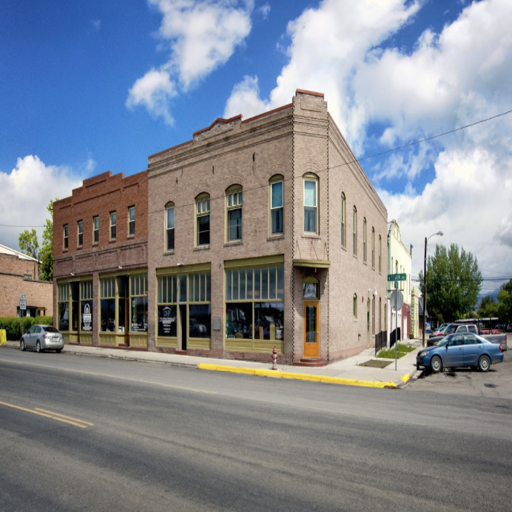

In [15]:
url = "https://images.squarespace-cdn.com/content/v1/5f0f175cf843e20f1d41be2e/1628693285665-N22RY9BIGMDXXEG15KAY/Borden+hotel+exterior+corner+Whitehall+MT.png"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))
display(init_image)

## mask = Image.open("mask.png").convert("L") 
## edited = pipe(prompt=prompt, image=image, mask_image=mask).images[0]

In [22]:

prompt = "a realistic european street with a single two-story building, " \
         "soft cinematic lighting, detailed textures, slightly cloudy sky, photorealistic, depth of field, clean perspective"

  0%|          | 0/37 [00:00<?, ?it/s]

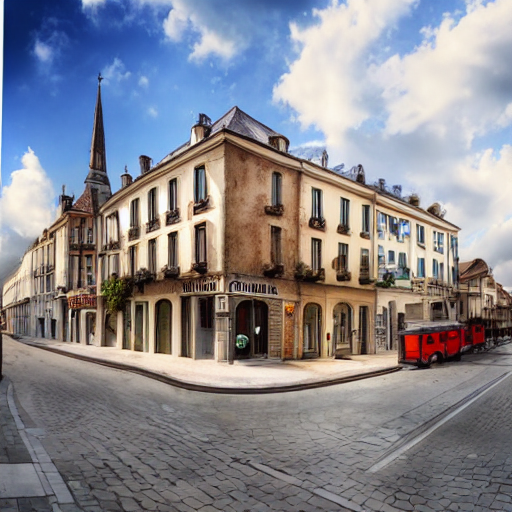

In [23]:
image = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]
display(image)

In [26]:
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

mask_model = maskrcnn_resnet50_fpn(pretrained=True)
mask_model.eval()

/Users/stell/Desktop/semfe_lab/semfe_lab/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/stell/Desktop/semfe_lab/semfe_lab/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /Users/stell/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:27<00:00, 6.41MB/s] 


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [46]:
def create_segformer_mask(model, processor, product_image):
    """
    :inputs:
        model:
        processor:
        product_image:
        division:

    outputs:
    """
    masks = predict_mask(model, processor, product_image)
    masks_pixel_sums = {
        "Tops":  np.sum(masks['Tops']),
        "Bottoms": np.sum(masks['Bottoms']),
        "Dresses & Sets": np.sum(masks['Dresses & Sets']),
        }

    if masks_pixel_sums['Tops'] + masks_pixel_sums['Bottoms'] + masks_pixel_sums['Dresses & Sets'] == 0:
        return False

    biggest_garment_division = max(masks_pixel_sums, key=masks_pixel_sums.get)

    final_image = np.array(product_image) * np.stack((masks[ biggest_garment_division ],) * 3, axis=-1)
    final_dict = { biggest_garment_division : Image.fromarray( final_image.astype( np.uint8 ))}

    return final_dict

In [45]:
import torch.nn as nn
def predict_mask(model, processor, product_image):

    """
    Parameters
    ----------
    model: masking model
    processor: masking processor
    product_image: image to be maskes

    Returns
    -------
    all masks in the form of a dict
    The masks are:
    
    """

    inputs = processor(images=product_image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    logits = outputs.logits

    upsampled_logits = nn.functional.interpolate(
        logits,
        size=product_image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    predicted_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

    # TOPS
    predicted_top = predicted_mask == 4

    #BOTTOMS
    predicted_skirt = predicted_mask == 5
    predicted_pants = predicted_mask == 6
    predicted_bottoms = predicted_skirt + predicted_pants

    #DRESSES
    predicted_dress = predicted_mask == 7

    masks = {
        "Tops": predicted_top,
        "Bottoms": predicted_bottoms,
        "Dresses & Sets": predicted_dress,
        }
    return masks

In [39]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

In [40]:
masking_processor = SegformerImageProcessor.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = AutoModelForSemanticSegmentation.from_pretrained("sayeed99/segformer_b3_clothes")
masking_model = masking_model.to(device)


preprocessor_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

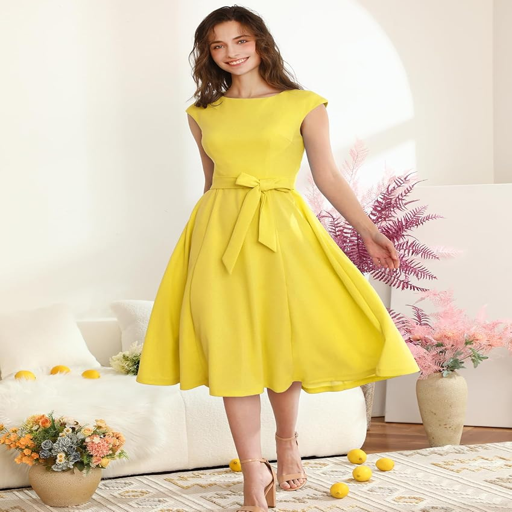

{'Dresses & Sets': <PIL.Image.Image image mode=RGB size=512x512 at 0x35A3F1B10>}


In [54]:
url = "https://m.media-amazon.com/images/I/71+FM+h-qXL._AC_UY1100_.jpg"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))
display(init_image)
masked_images = create_segformer_mask(masking_model, masking_processor, init_image)
print(masked_images)

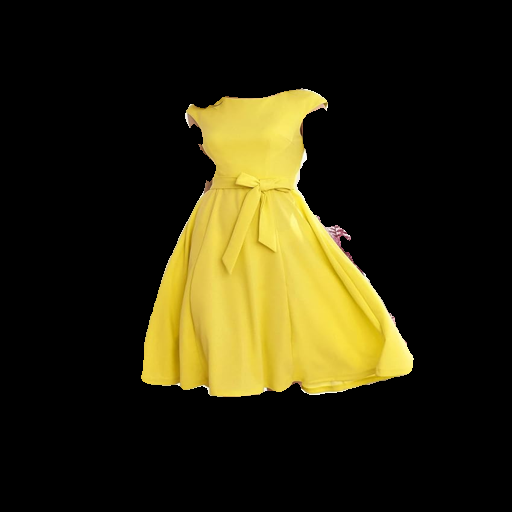

In [55]:
display(masked_images['Dresses & Sets'])

In [56]:
mask =masked_images['Dresses & Sets'].convert("L") 
edited = pipe(prompt='change the dress color to blue', image=init_image, mask_image=mask).images[0]

  0%|          | 0/40 [00:00<?, ?it/s]

In [59]:
import numpy as np
from PIL import Image

# Convert to L mode just in case
mask = masked_images['Dresses & Sets'].convert("L")

# Invert: white -> black, black -> white
mask_inverted = Image.fromarray(255 - np.array(mask))

edited = pipe(
    prompt='change the dress color to blue',
    image=init_image,
    mask_image=mask_inverted,
    guidance_scale=7.5
).images[0]

edited.show()

  0%|          | 0/40 [00:00<?, ?it/s]

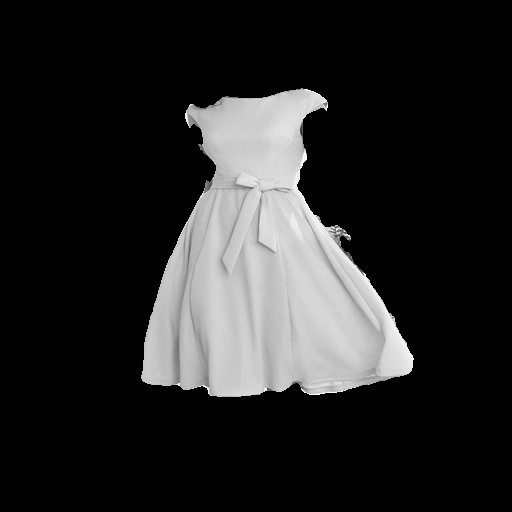

In [58]:
display(mask)